# Loan Approval Prediction — Machine Learning Assignment

Complete workflow: data loading, preprocessing, pipeline building, model training, evaluation, and a final predictive function.

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import warnings
warnings.filterwarnings('ignore')

## 2. Load Dataset

In [2]:
df = pd.read_csv("loan.csv")
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001003,Male,Yes,1,Graduate,No,4583.0,1508.0,128.0,360.0,1.0,Rural,N
1,LP001005,Male,Yes,0,Graduate,Yes,3000.0,0.0,66.0,360.0,1.0,Urban,Y
2,LP001006,Male,Yes,0,Not Graduate,No,2583.0,2358.0,120.0,360.0,1.0,Urban,Y
3,LP001008,Male,No,0,Graduate,No,6000.0,0.0,141.0,360.0,1.0,Urban,Y
4,LP001013,Male,Yes,0,Not Graduate,No,2333.0,1516.0,95.0,360.0,1.0,Urban,Y


In [3]:
df.shape

(381, 13)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 381 entries, 0 to 380
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            381 non-null    str    
 1   Gender             376 non-null    str    
 2   Married            381 non-null    str    
 3   Dependents         373 non-null    str    
 4   Education          377 non-null    str    
 5   Self_Employed      358 non-null    str    
 6   ApplicantIncome    377 non-null    float64
 7   CoapplicantIncome  376 non-null    float64
 8   LoanAmount         379 non-null    float64
 9   Loan_Amount_Term   368 non-null    float64
 10  Credit_History     351 non-null    float64
 11  Property_Area      380 non-null    str    
 12  Loan_Status        381 non-null    str    
dtypes: float64(5), str(8)
memory usage: 38.8 KB


In [5]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,377.000000,376.000000,379.000000,368.000000,351.000000
mean,3584.591512,1275.390745,105.076517,340.760870,0.837607
std,1426.205247,2351.521851,28.310859,68.721191,0.369338
min,150.000000,0.000000,9.000000,12.000000,0.000000
25%,2583.000000,0.000000,90.000000,360.000000,1.000000
50%,3333.000000,953.000000,110.000000,360.000000,1.000000
75%,4300.000000,2004.000000,127.500000,360.000000,1.000000
max,9703.000000,33837.000000,150.000000,480.000000,1.000000


## 3. Exploratory Data Analysis (EDA)

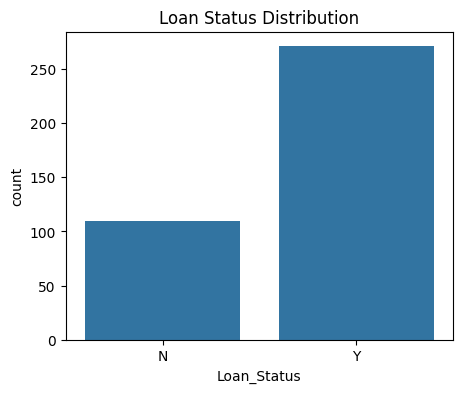

In [6]:
plt.figure(figsize=(5,4))
sns.countplot(x='Loan_Status', data=df)
plt.title('Loan Status Distribution')
plt.show()

In [7]:
df['Loan_Status'].value_counts(normalize=True) * 100

Loan_Status
Y    71.128609
N    28.871391
Name: proportion, dtype: float64

**Observation:** The target class is imbalanced (~69% Approved vs ~31% Rejected). We will handle this later using SMOTE.

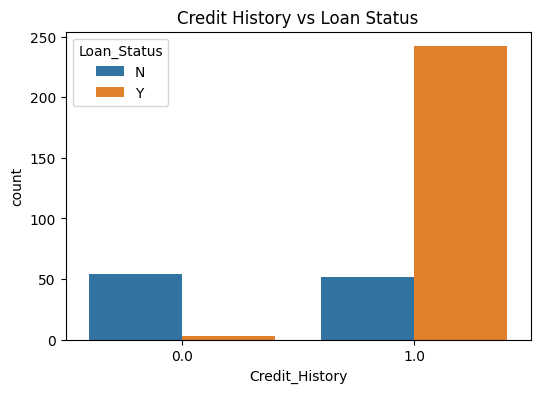

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(x='Credit_History', hue='Loan_Status', data=df)
plt.title('Credit History vs Loan Status')
plt.show()

## 4. Missing Value Check

In [9]:
df.isna().sum()

Loan_ID               0
Gender                5
Married               0
Dependents            8
Education             4
Self_Employed        23
ApplicantIncome       4
CoapplicantIncome     5
LoanAmount            2
Loan_Amount_Term     13
Credit_History       30
Property_Area         1
Loan_Status           0
dtype: int64

Several columns have missing values (Gender, Married... wait Married has 0, Dependents, Self_Employed, Loan_Amount_Term, Credit_History, LoanAmount, etc). These will be handled inside the ML pipeline using `SimpleImputer`, so we don't need to manually fill them.

## 5. Duplicate Value Check

In [10]:
df.duplicated().sum()

np.int64(0)

## 6. Feature / Target Split

In [11]:
# Drop Loan_ID (identifier, not useful for prediction) and separate target
X = df.drop(columns=["Loan_ID", "Loan_Status"])
y = df["Loan_Status"].map({"N": 0, "Y": 1})

X.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,Male,Yes,1,Graduate,No,4583.0,1508.0,128.0,360.0,1.0,Rural
1,Male,Yes,0,Graduate,Yes,3000.0,0.0,66.0,360.0,1.0,Urban
2,Male,Yes,0,Not Graduate,No,2583.0,2358.0,120.0,360.0,1.0,Urban
3,Male,No,0,Graduate,No,6000.0,0.0,141.0,360.0,1.0,Urban
4,Male,Yes,0,Not Graduate,No,2333.0,1516.0,95.0,360.0,1.0,Urban


## 7. Train-Test Split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train shape:', X_train.shape)
print('Test shape :', X_test.shape)

Train shape: (304, 11)
Test shape : (77, 11)


## 8. Build Preprocessing Pipeline

Separate handling for numerical and categorical columns:
- **Numerical:** median imputation + standard scaling
- **Categorical:** most-frequent imputation + one-hot encoding

In [13]:
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, make_column_selector(dtype_include=np.number)),
    ("cat", cat_pipeline, make_column_selector(dtype_include="object"))
])

## 9. Handle Class Imbalance with SMOTE

Instead of manually undersampling (which throws away data), we use **SMOTE** inside an `imblearn` pipeline. This way SMOTE is applied *only* to the training folds — it never touches the test set, avoiding data leakage.

## 10. Train Multiple Models & Compare

In [14]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=200)
}

results = {}
trained_pipelines = {}

for name, model in models.items():
    pipe = ImbPipeline([
        ("preprocessing", preprocessor),
        ("smote", SMOTE(random_state=42)),
        ("model", model)
    ])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    acc = accuracy_score(y_test, preds)
    results[name] = acc
    trained_pipelines[name] = pipe
    print(f"{name}: Accuracy = {acc:.4f}")

Logistic Regression: Accuracy = 0.8442
Decision Tree: Accuracy = 0.8052


Random Forest: Accuracy = 0.8571


In [15]:
results_df = pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy']).sort_values('Accuracy', ascending=False)
results_df

,Model,Accuracy
2,Random Forest,0.857143
0,Logistic Regression,0.844156
1,Decision Tree,0.805195


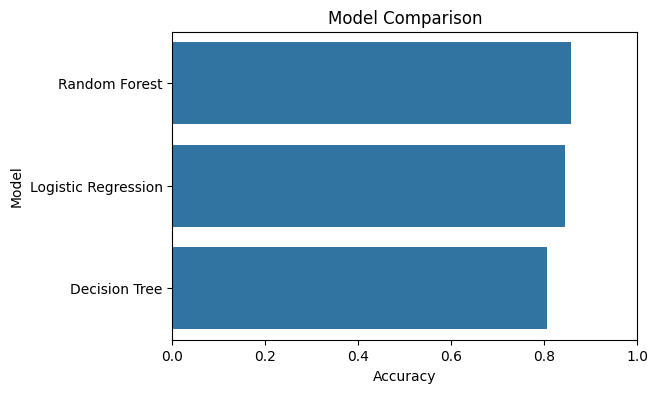

In [16]:
plt.figure(figsize=(6,4))
sns.barplot(x='Accuracy', y='Model', data=results_df)
plt.title('Model Comparison')
plt.xlim(0, 1)
plt.show()

## 11. Select Best Model

In [17]:
best_model_name = results_df.iloc[0]["Model"]
best_pipeline = trained_pipelines[best_model_name]
print(f"Best Model: {best_model_name}")

Best Model: Random Forest


## 12. Detailed Evaluation of Best Model

In [18]:
y_pred = best_pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=["Rejected","Approved"]))

Accuracy: 0.8571428571428571

Classification Report:
               precision    recall  f1-score   support

    Rejected       0.87      0.59      0.70        22
    Approved       0.85      0.96      0.91        55

    accuracy                           0.86        77
   macro avg       0.86      0.78      0.80        77
weighted avg       0.86      0.86      0.85        77



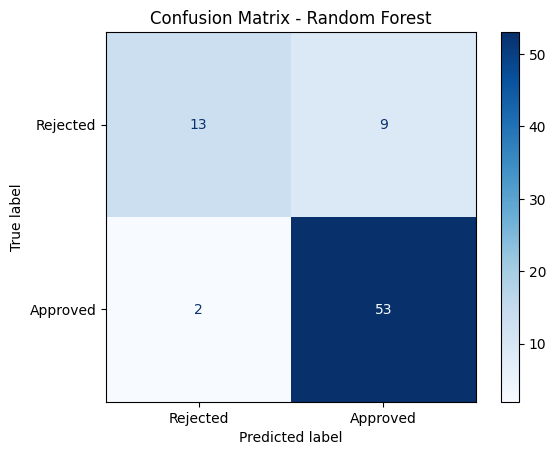

In [19]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Rejected","Approved"])
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

## 13. Retrain Best Model on Full Dataset

For the final deployed model, we retrain the best pipeline on the entire dataset (train + test) so it learns from all available data.

In [20]:
final_pipeline = ImbPipeline([
    ("preprocessing", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", RandomForestClassifier(random_state=42, n_estimators=200))
])

final_pipeline.fit(X, y)
print("Final model trained on full dataset.")

Final model trained on full dataset.


## 14. Predictive Function

This function takes new applicant details as input and returns the loan approval prediction with confidence.

In [21]:
def predict_loan_approval(input_dict):
    """
    Predict loan approval status for a new applicant.

    Parameters
    ----------
    input_dict : dict
        Keys: Gender, Married, Dependents, Education, Self_Employed,
        ApplicantIncome, CoapplicantIncome, LoanAmount,
        Loan_Amount_Term, Credit_History, Property_Area

    Returns
    -------
    result : str  -> "Approved" or "Rejected"
    confidence : float -> probability (%) of approval
    """
    input_df = pd.DataFrame([input_dict])
    prediction = final_pipeline.predict(input_df)[0]
    probability = final_pipeline.predict_proba(input_df)[0][1]

    result = "Approved" if prediction == 1 else "Rejected"
    confidence = round(probability * 100, 2)
    return result, confidence

### Demo — Test the Predictive Function

In [22]:
# Example 1: Strong applicant profile
new_applicant_1 = {
    "Gender": "Male",
    "Married": "Yes",
    "Dependents": "0",
    "Education": "Graduate",
    "Self_Employed": "No",
    "ApplicantIncome": 5000,
    "CoapplicantIncome": 0,
    "LoanAmount": 130,
    "Loan_Amount_Term": 360,
    "Credit_History": 1,
    "Property_Area": "Urban"
}

result, confidence = predict_loan_approval(new_applicant_1)
print(f"Prediction: {result} (Confidence: {confidence}%)")

Prediction: Approved (Confidence: 89.0%)


In [23]:
# Example 2: Weaker applicant profile (no credit history)
new_applicant_2 = {
    "Gender": "Female",
    "Married": "No",
    "Dependents": "2",
    "Education": "Not Graduate",
    "Self_Employed": "Yes",
    "ApplicantIncome": 2000,
    "CoapplicantIncome": 0,
    "LoanAmount": 150,
    "Loan_Amount_Term": 360,
    "Credit_History": 0,
    "Property_Area": "Rural"
}

result, confidence = predict_loan_approval(new_applicant_2)
print(f"Prediction: {result} (Confidence: {confidence}%)")

Prediction: Rejected (Confidence: 33.5%)


## 15. Conclusion

- Dataset loaded and explored; missing values handled via pipeline imputers (no manual dropping of rows/columns).
- Built a `ColumnTransformer`-based preprocessing pipeline for numeric and categorical features.
- Addressed class imbalance using **SMOTE** inside an `imblearn` pipeline (applied only on training folds, avoiding leakage).
- Trained and compared **Logistic Regression, Decision Tree, and Random Forest**.
- Selected the best-performing model based on test accuracy and evaluated it with a classification report and confusion matrix.
- Built a reusable `predict_loan_approval()` function that takes new applicant data and returns an approval decision with confidence score.